In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import fastparquet

In [2]:
df_taxi = pd.read_parquet("yellow_tripdata_2026-01.parquet", engine="fastparquet")
df_taxi.head(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,1.0,N,239,238,1,7.2,1.00,0.5,3.66,0.0,1.0,15.86,2.5,0.0,0.00
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0.0,0.90,1.0,N,163,162,2,7.9,4.25,0.5,0.00,0.0,1.0,13.65,2.5,0.0,0.75
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0.0,1.40,1.0,N,43,237,1,10.7,4.25,0.5,2.50,0.0,1.0,18.95,2.5,0.0,0.75
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,1.0,N,142,209,1,38.7,1.00,0.5,11.11,0.0,1.0,55.56,2.5,0.0,0.75
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0.0,2.16,1.0,N,88,144,1,13.5,1.00,0.5,3.85,0.0,1.0,23.10,2.5,0.0,0.75
5,2,2026-01-01 00:47:11,2026-01-01 01:00:47,2.0,2.33,1.0,N,144,137,1,14.2,1.00,0.5,4.99,0.0,1.0,24.94,2.5,0.0,0.75
6,1,2026-01-01 00:17:54,2026-01-01 00:28:32,1.0,1.30,1.0,N,142,50,2,11.4,4.25,0.5,0.00,0.0,1.0,17.15,2.5,0.0,0.75
7,1,2026-01-01 00:34:28,2026-01-01 00:59:05,0.0,2.90,1.0,N,50,234,1,22.6,4.25,0.5,5.65,0.0,1.0,34.00,2.5,0.0,0.75
8,2,2026-01-01 00:34:14,2026-01-01 01:11:58,1.0,5.34,1.0,N,161,45,1,37.3,1.00,0.5,8.61,0.0,1.0,51.66,2.5,0.0,0.75
9,2,2026-01-01 00:41:07,2026-01-01 00:50:42,3.0,1.83,1.0,N,237,263,1,10.7,1.00,0.5,2.36,0.0,1.0,18.06,2.5,0.0,0.00


In [3]:
print(f"df_taxi.shape {df_taxi.shape} \n{'='*50}\nand the df_texi.column is {df_taxi.columns}")

df_taxi.shape (3724889, 20) 
and the df_texi.column is Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'Airport_fee',
       'cbd_congestion_fee'],
      dtype='object')


In [4]:
print(f"shape {df_taxi.shape}\n\n missing value: {df_taxi.isnull().sum()}")

shape (3724889, 20)

 missing value: VendorID                       0
tpep_pickup_datetime           0
tpep_dropoff_datetime          0
passenger_count          1088058
trip_distance                  0
RatecodeID               1088058
store_and_fwd_flag       1088058
PULocationID                   0
DOLocationID                   0
payment_type                   0
fare_amount                    0
extra                          0
mta_tax                        0
tip_amount                     0
tolls_amount                   0
improvement_surcharge          0
total_amount                   0
congestion_surcharge     1088058
Airport_fee              1088058
cbd_congestion_fee             0
dtype: int64


In [5]:
df_taxi.nunique()

VendorID                       4
tpep_pickup_datetime     1757191
tpep_dropoff_datetime    1755995
passenger_count               10
trip_distance               4777
RatecodeID                     7
store_and_fwd_flag             2
PULocationID                 262
DOLocationID                 260
payment_type                   5
fare_amount                12867
extra                         45
mta_tax                        6
tip_amount                  4326
tolls_amount                1495
improvement_surcharge          4
total_amount               21228
congestion_surcharge           3
Airport_fee                    8
cbd_congestion_fee             3
dtype: int64

In [6]:
missing_percent = (df_taxi.isnull().sum() / len(df_taxi)) * 100
missing_percent

VendorID                  0.000000
tpep_pickup_datetime      0.000000
tpep_dropoff_datetime     0.000000
passenger_count          29.210481
trip_distance             0.000000
RatecodeID               29.210481
store_and_fwd_flag       29.210481
PULocationID              0.000000
DOLocationID              0.000000
payment_type              0.000000
fare_amount               0.000000
extra                     0.000000
mta_tax                   0.000000
tip_amount                0.000000
tolls_amount              0.000000
improvement_surcharge     0.000000
total_amount              0.000000
congestion_surcharge     29.210481
Airport_fee              29.210481
cbd_congestion_fee        0.000000
dtype: float64

In [7]:
df_taxi.dtypes

VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
Airport_fee                     float64
cbd_congestion_fee              float64
dtype: object

In [8]:
missing_column = []
for m in df_taxi.columns:
    if df_taxi[m].isnull().any():
        missing_column.append(m)

missing_column

['passenger_count',
 'RatecodeID',
 'store_and_fwd_flag',
 'congestion_surcharge',
 'Airport_fee']

In [9]:
for m in missing_column:
    print(df_taxi[m].unique())

[ 1.  0.  4.  2.  3.  5.  6.  9.  7.  8. nan]
[ 1.  4.  2.  5. 99.  3.  6. nan]
['N' 'Y' None]
[ 2.5  0.  -2.5  nan]
[ 0.    1.75  6.75 -1.75 20.    5.   21.75 26.75   nan]


In [10]:
df_taxi_clean = df_taxi.copy()

In [11]:
valid_passenger = df_taxi_clean[
    (df_taxi_clean['passenger_count'] >= 1) &
    (df_taxi_clean['passenger_count'] <= 6)
]['passenger_count']
valid_passenger

0          1.0
3          4.0
5          2.0
6          1.0
8          1.0
          ... 
2636826    1.0
2636827    1.0
2636828    1.0
2636829    4.0
2636830    1.0
Name: passenger_count, Length: 2622037, dtype: float64

In [12]:
passenger_median = valid_passenger.median()
passenger_median

1.0

In [13]:
df_taxi_clean['passenger_count'] = df_taxi_clean['passenger_count'].fillna(passenger_median)
df_taxi_clean['passenger_count'].isnull().sum()

np.int64(0)

<Axes: ylabel='passenger_count'>

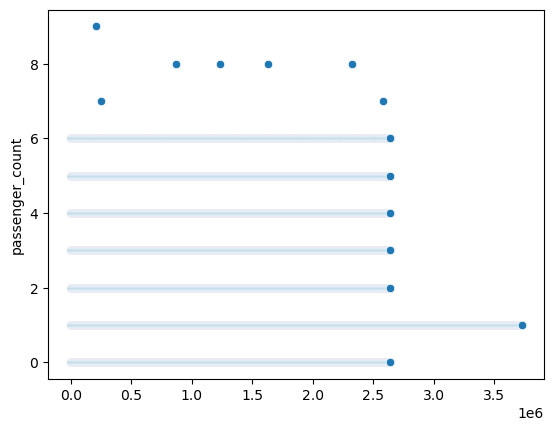

In [14]:
sns.scatterplot(df_taxi_clean['passenger_count'])

In [15]:
df_taxi_clean['RatecodeID'] = df_taxi_clean['RatecodeID'].fillna(99)
df_taxi_clean['RatecodeID'].isnull().sum()

np.int64(0)

In [16]:
df_taxi_clean["RatecodeID"].sample(10)

1819127     1.0
230817      1.0
3008648    99.0
1776355     1.0
3369490    99.0
1446656     2.0
759520      1.0
725823      1.0
28056       1.0
1190676     1.0
Name: RatecodeID, dtype: float64

In [17]:
df_taxi_clean['store_and_fwd_flag'] = df_taxi_clean['store_and_fwd_flag'].fillna('Unknown')
df_taxi_clean["store_and_fwd_flag"].sample(10)

426418           N
1383841          N
2782009    Unknown
1879244          N
3195440    Unknown
2273072          N
1885883          N
1239208          N
1318117          N
3332733    Unknown
Name: store_and_fwd_flag, dtype: object

In [18]:
df_taxi_clean['congestion_surcharge'] = df_taxi_clean['congestion_surcharge'].fillna(0)
df_taxi_clean['congestion_surcharge'].sample(10)

1842862    2.5
2066900    2.5
28913      2.5
2303210    2.5
448960     2.5
242180     2.5
2690228    0.0
2439018    2.5
34652      2.5
1632258    2.5
Name: congestion_surcharge, dtype: float64

In [19]:
df_taxi_clean['Airport_fee'] = df_taxi_clean['Airport_fee'].fillna(0)
df_taxi_clean['Airport_fee'].sample(10)

181246     0.00
1143884    0.00
2265894    1.75
381441     0.00
2735705    0.00
1677267    0.00
963669     1.75
3479948    0.00
1610286    0.00
3262858    0.00
Name: Airport_fee, dtype: float64

In [20]:
df_taxi_clean['passenger_count'] = df_taxi_clean['passenger_count'].astype(int)
df_taxi_clean['RatecodeID'] = df_taxi_clean['RatecodeID'].astype(int)

In [21]:
df_taxi_clean.dtypes

VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                   int64
trip_distance                   float64
RatecodeID                        int64
store_and_fwd_flag               object
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
Airport_fee                     float64
cbd_congestion_fee              float64
dtype: object

In [22]:
df_taxi_clean.isnull().sum()

VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
congestion_surcharge     0
Airport_fee              0
cbd_congestion_fee       0
dtype: int64

In [23]:
numerical_cols = df_taxi.select_dtypes(include=np.number).columns
print(f"numerical_cols are {numerical_cols.__len__()}")
print(numerical_cols)

numerical_cols are 17
Index(['VendorID', 'passenger_count', 'trip_distance', 'RatecodeID',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'Airport_fee',
       'cbd_congestion_fee'],
      dtype='object')


In [24]:
categorical_cols = df_taxi.select_dtypes(include="object").columns
print(f"categorical_cols are {categorical_cols.__len__()}")
print(categorical_cols)

categorical_cols are 1
Index(['store_and_fwd_flag'], dtype='object')


### Variable Classification for Yellow Taxi Dataset

| Column | Type | Subtype | Justification |
|---|---|---|---|
| VendorID | Categorical | Nominal | It is a vendor/provider code. The numbers are labels, not quantities. |
| tpep_pickup_datetime | Numerical/Temporal | Continuous | It represents pickup date and time, which changes continuously. |
| tpep_dropoff_datetime | Numerical/Temporal | Continuous | It represents dropoff date and time, which changes continuously. |
| passenger_count | Numerical | Discrete | It counts the number of passengers, so values are countable. |
| trip_distance | Numerical | Continuous | Distance is measurable and can contain decimal values. |
| RatecodeID | Categorical | Nominal | It represents rate type codes such as standard rate, JFK, Newark, etc. |
| store_and_fwd_flag | Categorical | Nominal | It has categories such as Y, N, or Unknown, with no natural order. |
| PULocationID | Categorical | Nominal | It is a pickup taxi zone code, not a mathematical value. |
| DOLocationID | Categorical | Nominal | It is a dropoff taxi zone code, not a mathematical value. |
| payment_type | Categorical | Nominal | It represents payment method codes such as credit card, cash, no charge, or dispute. |
| fare_amount | Numerical | Continuous | Fare is a measurable money amount and can contain decimals. |
| extra | Numerical | Continuous | Extra charge is a measurable money amount. |
| mta_tax | Numerical | Continuous | MTA tax is a money amount. |
| tip_amount | Numerical | Continuous | Tip is a measurable money amount and can contain decimals. |
| tolls_amount | Numerical | Continuous | Toll amount is a measurable money value. |
| improvement_surcharge | Numerical | Continuous | It is a surcharge amount measured in money. |
| total_amount | Numerical | Continuous | Total fare is a measurable money amount. |
| congestion_surcharge | Numerical | Continuous | It is a congestion charge amount measured in money. |
| Airport_fee | Numerical | Continuous | It is an airport fee amount measured in money. |
| cbd_congestion_fee | Numerical | Continuous | It is a congestion fee amount for Central Business District trips. |

In [25]:
fare_mean = df_taxi_clean['fare_amount'].mean()
fare_std = df_taxi_clean['fare_amount'].std()

print(f"{fare_mean} \n{fare_std}")

20.804253893203267 
18.927007021276765


In [26]:
meaningful_numeric_cols = []
for n in df_taxi_clean.columns:
    if pd.api.types.is_numeric_dtype(df_taxi_clean[n]):
        meaningful_numeric_cols.append(n)

meaningful_numeric_cols

['VendorID',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'Airport_fee',
 'cbd_congestion_fee']

In [27]:
range_values = df_taxi_clean[meaningful_numeric_cols].max() - df_taxi_clean[meaningful_numeric_cols].min()
print(range_values.sort_values(ascending=False))

trip_distance            269097.48
total_amount               5120.40
fare_amount                5110.40
tip_amount                  854.88
DOLocationID                264.00
PULocationID                264.00
tolls_amount                216.72
RatecodeID                   98.00
Airport_fee                  28.50
extra                        24.96
passenger_count               9.00
VendorID                      6.00
mta_tax                       5.25
congestion_surcharge          5.00
payment_type                  4.00
improvement_surcharge         2.00
cbd_congestion_fee            1.50
dtype: float64


In [28]:
largest_range_col = range_values.idxmax()
largest_range_value = range_values.max()

largest_range_col, largest_range_value

('trip_distance', 269097.48)

In [29]:
trip_distance_min = df_taxi_clean['trip_distance'].min()
trip_distance_max = df_taxi_clean['trip_distance'].max()

trip_distance_min, trip_distance_max

(0.0, 269097.48)

In [30]:
print(df_taxi_clean['trip_distance'].quantile([0.25, 0.50, 0.75, 0.95, 0.99, 0.999]))

0.250     1.00
0.500     1.81
0.750     3.73
0.950    12.45
0.990    19.54
0.999    29.79
Name: trip_distance, dtype: float64


In [31]:
df_taxi_clean['trip_distance_capped'] = df_taxi_clean['trip_distance'].clip(lower=0, upper=100)
print("Maximum trip_distance after capping:", df_taxi_clean['trip_distance_capped'].max())

Maximum trip_distance after capping: 100.0


In [32]:
trip_distance_mean = df_taxi_clean['trip_distance'].mean()
trip_distance_median = df_taxi_clean['trip_distance'].median()
trip_distance_mode = df_taxi_clean['trip_distance'].mode()[0]

print("Mean trip_distance:", trip_distance_mean)
print("Median trip_distance:", trip_distance_median)
print("Mode trip_distance:", trip_distance_mode)

Mean trip_distance: 6.455646860886331
Median trip_distance: 1.81
Mode trip_distance: 0.0


In [33]:
fare_range = df_taxi_clean['fare_amount'].max() - df_taxi_clean['fare_amount'].min()
fare_variance = df_taxi_clean['fare_amount'].var()
fare_std = df_taxi_clean['fare_amount'].std()

print("Range of fare_amount:", fare_range)
print("Variance of fare_amount:", fare_variance)
print("Standard deviation of fare_amount:", fare_std)

Range of fare_amount: 5110.4
Variance of fare_amount: 358.2315947834599
Standard deviation of fare_amount: 18.927007021276765


In [34]:
q1_tip = df_taxi_clean['tip_amount'].quantile(0.25)
q3_tip = df_taxi_clean['tip_amount'].quantile(0.75)
iqr_tip = q3_tip - q1_tip

print("Q1 of tip_amount:", q1_tip)
print("Q3 of tip_amount:", q3_tip)
print("IQR of tip_amount:", iqr_tip)

Q1 of tip_amount: 0.0
Q3 of tip_amount: 3.71
IQR of tip_amount: 3.71


In [35]:
df_taxi_clean['tpep_pickup_datetime'] = pd.to_datetime(df_taxi_clean['tpep_pickup_datetime'])
df_taxi_clean['tpep_dropoff_datetime'] = pd.to_datetime(df_taxi_clean['tpep_dropoff_datetime'])

df_taxi_clean[['tpep_pickup_datetime', 'tpep_dropoff_datetime']].head()

,tpep_pickup_datetime,tpep_dropoff_datetime
0,2026-01-01 00:54:04,2026-01-01 00:59:37
1,2026-01-01 00:34:04,2026-01-01 00:39:47
2,2026-01-01 00:57:06,2026-01-01 01:05:59
3,2026-01-01 00:15:22,2026-01-01 00:58:10
4,2026-01-01 00:27:13,2026-01-01 00:40:43


In [36]:
df_taxi_clean['trip_duration_min'] = (
    df_taxi_clean['tpep_dropoff_datetime'] - df_taxi_clean['tpep_pickup_datetime']
).dt.total_seconds() / 60

df_taxi_clean['pickup_dayofweek'] = df_taxi_clean['tpep_pickup_datetime'].dt.dayofweek
df_taxi_clean['is_weekend'] = (df_taxi_clean['pickup_dayofweek'] >= 5).astype(int)

df_taxi_clean[['trip_duration_min', 'pickup_dayofweek', 'is_weekend']].head()

,trip_duration_min,pickup_dayofweek,is_weekend
0,5.550000,3,0
1,5.716667,3,0
2,8.883333,3,0
3,42.800000,3,0
4,13.500000,3,0


In [37]:
df_taxi_clean['tip_percentage'] = np.where(
    df_taxi_clean['fare_amount'] > 0,
    (df_taxi_clean['tip_amount'] / df_taxi_clean['fare_amount']) * 100,
    np.nan
)
df_taxi_clean['tip_percentage'].head()

0    50.833333
1     0.000000
2    23.364486
3    28.708010
4    28.518519
Name: tip_percentage, dtype: float64

In [38]:
df_taxi_clean['distance_bin'] = pd.cut(
    df_taxi_clean['trip_distance'],
    bins=[0, 1, 3, 5, 10, 100],
    labels=['Very Short', 'Short', 'Medium', 'Long', 'Very Long'],
    include_lowest=True
)
df_taxi_clean['distance_bin'].sample(10)

2729869    Very Short
1516183         Short
2226035          Long
3279309    Very Short
2022391         Short
2512612         Short
3537000          Long
1191609    Very Short
3499190    Very Short
3379880         Short
Name: distance_bin, dtype: category
Categories (5, object): ['Very Short' < 'Short' < 'Medium' < 'Long' < 'Very Long']

### 1. Is the distribution of trip_distance symmetric or skewed? Justify by comparing mean and median.

In [39]:
trip_mean = df_taxi_clean['trip_distance'].mean()
trip_median = df_taxi_clean['trip_distance'].median()

print(f"mean and median {trip_mean} and {trip_median}")

if trip_mean > trip_median:
    print("The distribution is right-skewed.")
elif trip_mean < trip_median:
    print("The distribution is left-skewed.")
else:
    print("The distribution is approximately symmetric.")

mean and median 6.455646860886331 and 1.81
The distribution is right-skewed.


### 2. Which measure of central tendency is most appropriate for passenger_count? Why?

In [40]:
print("\n2. Passenger Count Mean:", df_taxi_clean['passenger_count'].mean())
print("Passenger Count Median:", df_taxi_clean['passenger_count'].median())
print("Passenger Count Mode:", df_taxi_clean['passenger_count'].mode()[0])


2. Passenger Count Mean: 1.1814131911044865
Passenger Count Median: 1.0
Passenger Count Mode: 1


Text(0.5, 1.0, 'Passenger Count Distribution')

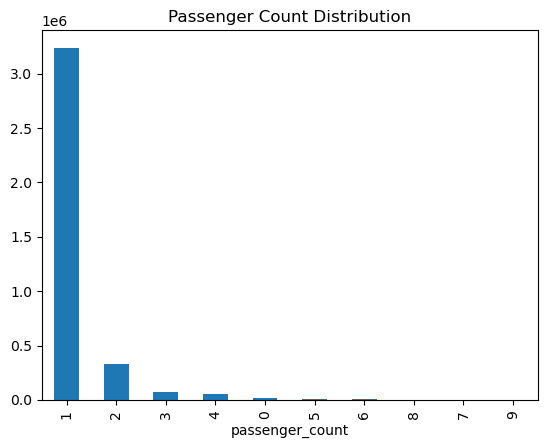

In [41]:
df_taxi_clean['passenger_count'].value_counts().plot(kind='bar')
plt.title('Passenger Count Distribution')

### 3. Why might tip_amount have a large IQR?

In [42]:
tip_q1 = df_taxi_clean['tip_amount'].quantile(0.25)
tip_q3 = df_taxi_clean['tip_amount'].quantile(0.75)
tip_iqr = tip_q3 - tip_q1

print("\n3. Tip Amount Q1:", tip_q1)
print("Tip Amount Q3:", tip_q3)
print("Tip Amount IQR:", tip_iqr)


3. Tip Amount Q1: 0.0
Tip Amount Q3: 3.71
Tip Amount IQR: 3.71


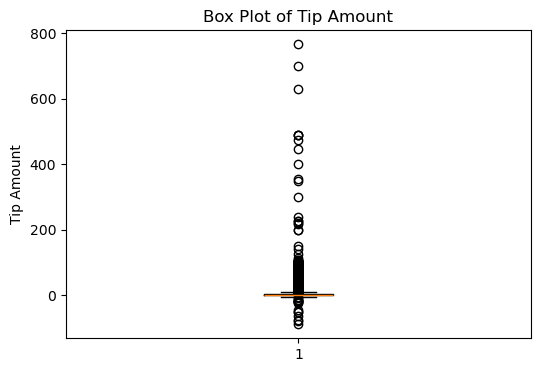

In [43]:
plt.figure(figsize=(6, 4))
plt.boxplot(df_taxi_clean["tip_amount"].dropna())
plt.title("Box Plot of Tip Amount")
plt.ylabel("Tip Amount")
plt.show()

### 4. Print the 25th, 50th, and 75th percentiles of total_amount

In [44]:
df_taxi_clean["total_amount"].describe()

count    3.724889e+06
mean     2.917853e+01
std      2.258553e+01
min     -2.560200e+03
25%      1.700000e+01
50%      2.305000e+01
75%      3.383000e+01
max      2.560200e+03
Name: total_amount, dtype: float64

In [45]:
total_percentiles = df_taxi_clean['total_amount'].quantile([0.25, 0.50, 0.75])
print(total_percentiles)

0.25    17.00
0.50    23.05
0.75    33.83
Name: total_amount, dtype: float64


### 5. What is the most common payment type? What percentage of trips use it?

Text(0.5, 1.0, 'Payment Type Distribution')

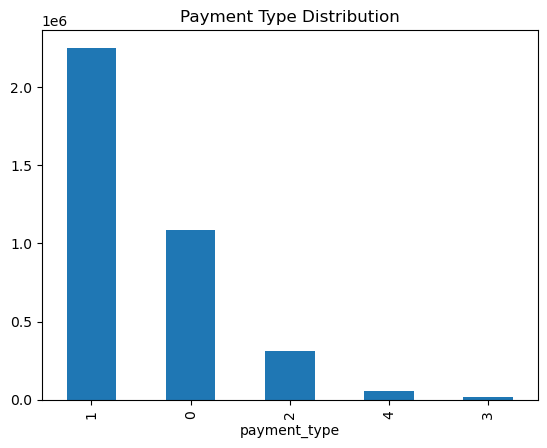

In [46]:
df_taxi_clean["payment_type"].value_counts().plot(kind='bar')
plt.title('Payment Type Distribution')

In [47]:
payment_counts = df_taxi_clean['payment_type'].value_counts()
payment_percent = df_taxi_clean['payment_type'].value_counts(normalize=True) * 100

most_common_payment = payment_counts.idxmax()
most_common_payment_percent = payment_percent.loc[most_common_payment]

print("\n5. Most common payment type:", most_common_payment)
print("Percentage:", most_common_payment_percent)


5. Most common payment type: 1
Percentage: 60.39769238761209


### 6. Create a bar chart showing the count of trips by payment_type.

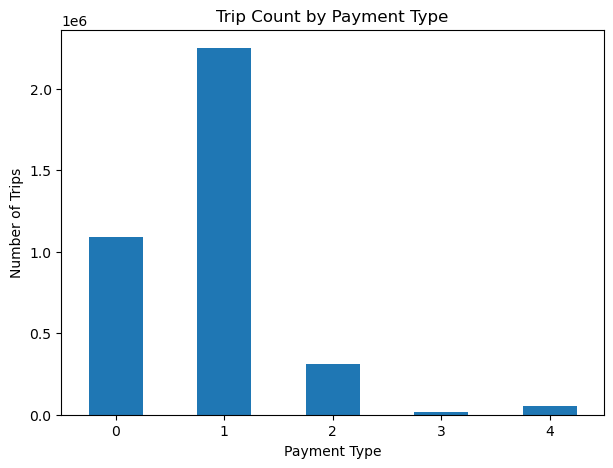

In [48]:
plt.figure(figsize=(7, 5))
df_taxi_clean['payment_type'].value_counts().sort_index().plot(kind='bar')
plt.title('Trip Count by Payment Type')
plt.xlabel('Payment Type')
plt.ylabel('Number of Trips')
plt.xticks(rotation=0)
plt.show()

### 7. What does store_and_fwd_flag = 'Y' mean? What percentage of trips have this flag?

Text(0.5, 1.0, 'Store and Forward Flag Distribution')

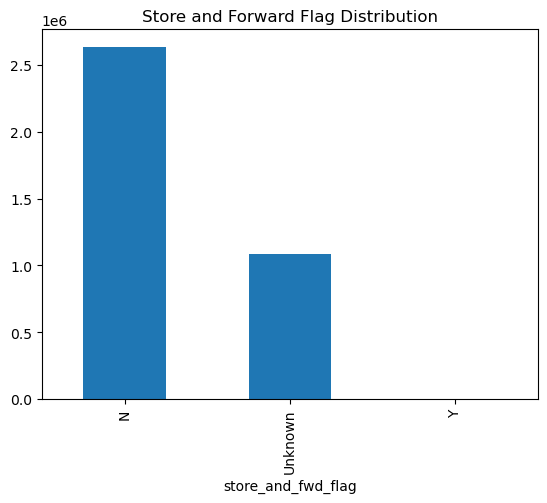

In [49]:
df_taxi_clean["store_and_fwd_flag"].value_counts().plot(kind='bar')
plt.title('Store and Forward Flag Distribution')

In [50]:
store_flag_percent = (df_taxi_clean['store_and_fwd_flag'].value_counts(normalize=True) * 100)
print(store_flag_percent)

store_and_fwd_flag
N          70.726779
Unknown    29.210481
Y           0.062740
Name: proportion, dtype: float64


### 8. Create a pie chart for store_and_fwd_flag.

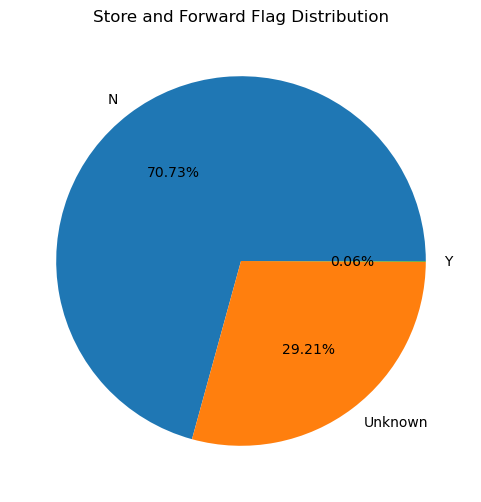

In [51]:
plt.figure(figsize=(6, 6))
df_taxi_clean['store_and_fwd_flag'].value_counts().plot(
    kind='pie',
    autopct='%1.2f%%'
)
plt.title('Store and Forward Flag Distribution')
plt.ylabel('')
plt.show()


### 9. Average fare_amount for payment_type = 1 (Credit card) vs. 2 (Cash).

Text(0.5, 1.0, 'Payment Type Distribution')

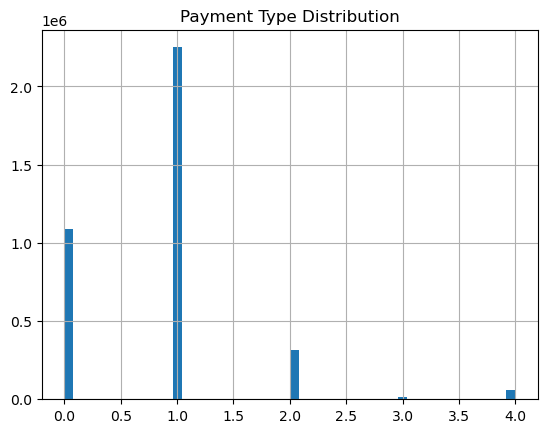

In [52]:
df_taxi_clean["payment_type"].hist(bins=50)
plt.title('Payment Type Distribution')

In [53]:
# df_taxi_clean[["payment_type", "fare_amount"]].describe()
df_taxi_clean[["payment_type", "fare_amount"]].groupby('payment_type').describe().T

payment_type                  0             1              2             3  \
fare_amount count  1.088058e+06  2.249747e+06  314043.000000  16641.000000   
            mean   2.537934e+01  1.955885e+01      18.134862      6.567153   
            std    1.442761e+01  1.852767e+01      22.897936     45.418652   
            min   -4.229000e+01 -8.500000e+01    -826.200000  -2555.200000   
            25%    1.557000e+01  9.300000e+00       7.900000     -3.000000   
            50%    2.221000e+01  1.350000e+01      12.100000      5.800000   
            75%    3.151000e+01  2.190000e+01      21.200000     13.500000   
            max    6.801900e+02  2.500000e+03     899.000000   2555.200000   

payment_type                  4  
fare_amount count  56400.000000  
            mean       1.284915  
            std       38.422337  
            min     -900.000000  
            25%      -12.100000  
            50%        3.000000  
            75%       13.500000  
            max      900.000000

In [54]:
avg_fare_payment = df_taxi_clean[df_taxi_clean['payment_type'].isin([1, 2])].groupby('payment_type')['fare_amount'].mean()

print("\n9. Average fare_amount for Credit Card vs Cash:")
print(avg_fare_payment)


9. Average fare_amount for Credit Card vs Cash:
payment_type
1    19.558851
2    18.134862
Name: fare_amount, dtype: float64


### 10. Average tip_amount for credit card vs. cash trips.

In [55]:
avg_tip_payment = df_taxi_clean[df_taxi_clean['payment_type'].isin([1, 2])].groupby('payment_type')['tip_amount'].mean()

print("\n10. Average tip_amount for Credit Card vs Cash:")
print(avg_tip_payment)


10. Average tip_amount for Credit Card vs Cash:
payment_type
1    4.136821
2    0.000426
Name: tip_amount, dtype: float64


### 11. For trips with passenger_count = 1, what is the average trip_distance?

In [56]:
df_taxi_clean[["passenger_count", "trip_distance"]].head()

,passenger_count,trip_distance
0,1,0.97
1,0,0.90
2,0,1.40
3,4,5.58
4,0,2.16


In [57]:
df_taxi_clean[["passenger_count", "trip_distance"]].describe()

,passenger_count,trip_distance
count,3.724889e+06,3.724889e+06
mean,1.181413e+00,6.455647e+00
std,5.758342e-01,6.488855e+02
min,0.000000e+00,0.000000e+00
25%,1.000000e+00,1.000000e+00
50%,1.000000e+00,1.810000e+00
75%,1.000000e+00,3.730000e+00
max,9.000000e+00,2.690975e+05


In [58]:
pass_trip = df_taxi_clean.query("passenger_count == 1")["trip_distance"]
pass_trip

0          0.97
6          1.30
8          5.34
10         3.09
11         1.26
           ... 
3724884    1.62
3724885    0.00
3724886    6.84
3724887    1.53
3724888    1.04
Name: trip_distance, Length: 3239052, dtype: float64

In [59]:
avg_distance_single_passenger = df_taxi_clean[df_taxi_clean['passenger_count'] == 1]['trip_distance'].mean()

print("\n11. Average trip_distance for passenger_count = 1:")
print(avg_distance_single_passenger)


11. Average trip_distance for passenger_count = 1:
6.847683751295138


### 12. Calculate the standard deviation of trip_distance for trips with VendorID = 1 and VendorID = 2.

In [60]:
std_distance_vendor = df_taxi_clean[df_taxi_clean['VendorID'].isin([1, 2])].groupby('VendorID')['trip_distance'].std()

print("\n12. Standard deviation of trip_distance by VendorID:")
print(std_distance_vendor)



12. Standard deviation of trip_distance by VendorID:
VendorID
1      4.634073
2    727.201742
Name: trip_distance, dtype: float64


### 13. Calculate the skewness of fare_amount for trips with tip_amount > 0.

In [61]:
fare_skew_tip_positive = df_taxi_clean[df_taxi_clean['tip_amount'] > 0]['fare_amount'].skew()

print("\n13. Skewness of fare_amount for trips with tip_amount > 0:")
print(fare_skew_tip_positive)


13. Skewness of fare_amount for trips with tip_amount > 0:
3.589582955044719


### 14. Mean difference of total_amount between trips that paid Airport_fee (>0) and those that did not.

Text(0.5, 1.0, 'Airport Fee Distribution')

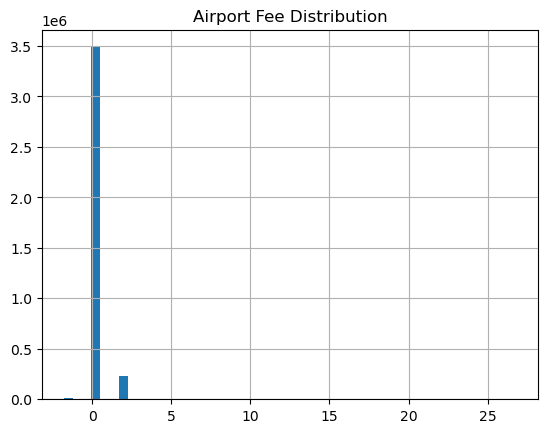

In [62]:
df_taxi_clean["Airport_fee"].hist(bins=50)
plt.title('Airport Fee Distribution')

In [63]:
df_taxi_clean["Airport_fee"].describe()

count    3.724889e+06
mean     1.049765e-01
std      4.540479e-01
min     -1.750000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      2.675000e+01
Name: Airport_fee, dtype: float64

In [64]:
df_taxi_clean['tip_amount'].unique()

array([ 3.66,  0.  ,  2.5 , ..., 31.02, 38.39, 60.81])

In [65]:
df_taxi_clean["total_amount"].describe()

count    3.724889e+06
mean     2.917853e+01
std      2.258553e+01
min     -2.560200e+03
25%      1.700000e+01
50%      2.305000e+01
75%      3.383000e+01
max      2.560200e+03
Name: total_amount, dtype: float64

In [66]:
avg_total_airport = df_taxi_clean.groupby(df_taxi_clean['Airport_fee'] > 0)['total_amount'].mean()
print(avg_total_airport)

Airport_fee
False    26.173144
True     75.191715
Name: total_amount, dtype: float64


In [67]:
airport_paid_mean = avg_total_airport.loc[True]
airport_not_paid_mean = avg_total_airport.loc[False]

mean_difference_airport = airport_paid_mean - airport_not_paid_mean
print("Mean difference:", mean_difference_airport)

Mean difference: 49.0185711586591


### 15. What is the average trip_duration_min for weekend trips vs. weekday trips?

In [68]:
avg_duration_weekend = df_taxi_clean.groupby('is_weekend')['trip_duration_min'].mean()

print("\n15. Average trip_duration_min for weekday vs weekend:")
print(avg_duration_weekend)



15. Average trip_duration_min for weekday vs weekend:
is_weekend
0    17.884759
1    15.421457
Name: trip_duration_min, dtype: float64


### 16. What is the average tip_percentage for credit card payments?

In [69]:
avg_tip_percentage_credit = df_taxi_clean[df_taxi_clean['payment_type'] == 1]['tip_percentage'].mean()

print("\n16. Average tip_percentage for credit card payments:")
print(avg_tip_percentage_credit)


16. Average tip_percentage for credit card payments:
25.522722922603382


### 17. Create a distance_bin column using pd.cut() with bins: [0, 1, 3, 5, 10, 100] and labels ['Very Short','Short','Medium','Long','Very Long'].

In [70]:
df_taxi_clean['distance_bin'] = pd.cut(
    df_taxi_clean['trip_distance'], 
    bins=[0, 1, 3, 5, 10, 100], 
    labels=['Very Short', 'Short', 'Medium', 'Long', 'Very Long'],
    include_lowest=True
)

print(df_taxi_clean[['trip_distance', 'distance_bin']].head())

   trip_distance distance_bin
0           0.97   Very Short
1           0.90   Very Short
2           1.40        Short
3           5.58         Long
4           2.16        Short


### 18. Count the number of trips in each distance_bin.

In [71]:
distance_bin_count = df_taxi_clean['distance_bin'].value_counts().sort_index()

print("\n18. Number of trips in each distance_bin:")
print(distance_bin_count)


18. Number of trips in each distance_bin:
distance_bin
Very Short     940249
Short         1633452
Medium         458120
Long           413556
Very Long      279350
Name: count, dtype: int64


In [72]:
df_ml = df_taxi_clean.copy()

In [73]:
df_ml.head(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,trip_distance_capped,trip_duration_min,pickup_dayofweek,is_weekend,tip_percentage,distance_bin
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1,0.97,1,N,239,238,1,...,15.86,2.5,0.0,0.00,0.97,5.550000,3,0,50.833333,Very Short
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0,0.90,1,N,163,162,2,...,13.65,2.5,0.0,0.75,0.90,5.716667,3,0,0.000000,Very Short
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0,1.40,1,N,43,237,1,...,18.95,2.5,0.0,0.75,1.40,8.883333,3,0,23.364486,Short
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4,5.58,1,N,142,209,1,...,55.56,2.5,0.0,0.75,5.58,42.800000,3,0,28.708010,Long
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0,2.16,1,N,88,144,1,...,23.10,2.5,0.0,0.75,2.16,13.500000,3,0,28.518519,Short
5,2,2026-01-01 00:47:11,2026-01-01 01:00:47,2,2.33,1,N,144,137,1,...,24.94,2.5,0.0,0.75,2.33,13.600000,3,0,35.140845,Short
6,1,2026-01-01 00:17:54,2026-01-01 00:28:32,1,1.30,1,N,142,50,2,...,17.15,2.5,0.0,0.75,1.30,10.633333,3,0,0.000000,Short
7,1,2026-01-01 00:34:28,2026-01-01 00:59:05,0,2.90,1,N,50,234,1,...,34.00,2.5,0.0,0.75,2.90,24.616667,3,0,25.000000,Short
8,2,2026-01-01 00:34:14,2026-01-01 01:11:58,1,5.34,1,N,161,45,1,...,51.66,2.5,0.0,0.75,5.34,37.733333,3,0,23.083110,Long
9,2,2026-01-01 00:41:07,2026-01-01 00:50:42,3,1.83,1,N,237,263,1,...,18.06,2.5,0.0,0.00,1.83,9.583333,3,0,22.056075,Short


#### if "tpep_dropoff_datetime","tpep_pickup_datetime" this 2 is already datetime type then no need to change.

In [74]:
# df_ml['tpep_pickup_datetime'] = pd.to_datetime(df_ml['tpep_pickup_datetime'])
# df_ml['tpep_dropoff_datetime'] = pd.to_datetime(df_ml['tpep_dropoff_datetime'])

In [75]:
df_ml[["tpep_dropoff_datetime","tpep_pickup_datetime"]].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3724889 entries, 0 to 3724888
Data columns (total 2 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   tpep_dropoff_datetime  datetime64[us]
 1   tpep_pickup_datetime   datetime64[us]
dtypes: datetime64[us](2)
memory usage: 56.8 MB


In [76]:
df_ml['trip_duration_min'] = (
    df_ml['tpep_dropoff_datetime'] - df_ml['tpep_pickup_datetime']
).dt.total_seconds() / 60

df_ml["trip_duration_min"].head()

0     5.550000
1     5.716667
2     8.883333
3    42.800000
4    13.500000
Name: trip_duration_min, dtype: float64

In [77]:
df_ml['pickup_hour'] = df_ml['tpep_pickup_datetime'].dt.hour
df_ml['pickup_dayofweek'] = df_ml['tpep_pickup_datetime'].dt.dayofweek
df_ml['is_weekend'] = (df_ml['pickup_dayofweek'] >= 5).astype(int)

In [78]:
df_ml[["pickup_hour", "pickup_dayofweek", "is_weekend"]].head()

,pickup_hour,pickup_dayofweek,is_weekend
0,0,3,0
1,0,3,0
2,0,3,0
3,0,3,0
4,0,3,0


In [79]:
df_ml[["pickup_hour", "pickup_dayofweek", "is_weekend"]].describe()

,pickup_hour,pickup_dayofweek,is_weekend
count,3.724889e+06,3.724889e+06,3.724889e+06
mean,1.411313e+01,3.136847e+00,2.807608e-01
std,5.984992e+00,1.831234e+00,4.493709e-01
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.000000e+01,2.000000e+00,0.000000e+00
50%,1.500000e+01,3.000000e+00,0.000000e+00
75%,1.900000e+01,5.000000e+00,1.000000e+00
max,2.300000e+01,6.000000e+00,1.000000e+00


In [80]:
df_ml['hour_sin'] = np.sin(2 * np.pi * df_ml['pickup_hour'] / 24)
df_ml['hour_cos'] = np.cos(2 * np.pi * df_ml['pickup_hour'] / 24)

df_ml['dow_sin'] = np.sin(2 * np.pi * df_ml['pickup_dayofweek'] / 7)
df_ml['dow_cos'] = np.cos(2 * np.pi * df_ml['pickup_dayofweek'] / 7)

In [81]:
df_ml[["hour_sin","hour_cos","dow_sin","dow_cos"]].head()

,hour_sin,hour_cos,dow_sin,dow_cos
0,0.0,1.0,0.433884,-0.900969
1,0.0,1.0,0.433884,-0.900969
2,0.0,1.0,0.433884,-0.900969
3,0.0,1.0,0.433884,-0.900969
4,0.0,1.0,0.433884,-0.900969


In [82]:
df_ml["passenger_count"].describe(), df_ml["passenger_count"].unique()

(count    3.724889e+06
 mean     1.181413e+00
 std      5.758342e-01
 min      0.000000e+00
 25%      1.000000e+00
 50%      1.000000e+00
 75%      1.000000e+00
 max      9.000000e+00
 Name: passenger_count, dtype: float64,
 array([1, 0, 4, 2, 3, 5, 6, 9, 7, 8]))

In [83]:
df_ml.loc[~df_ml['passenger_count'].between(1, 6), 'passenger_count'] = np.nan

In [84]:
df_ml["passenger_count"].describe(), df_ml["passenger_count"].unique()

(count    3.710095e+06
 mean     1.186109e+00
 std      5.720467e-01
 min      1.000000e+00
 25%      1.000000e+00
 50%      1.000000e+00
 75%      1.000000e+00
 max      6.000000e+00
 Name: passenger_count, dtype: float64,
 array([ 1., nan,  4.,  2.,  3.,  5.,  6.]))

In [85]:
df_ml['passenger_count'] = df_ml['passenger_count'].fillna(df_ml['passenger_count'].median()).astype(int)

In [86]:
df_ml["passenger_count"].describe(), df_ml["passenger_count"].unique()

(count    3.724889e+06
 mean     1.185370e+00
 std      5.710296e-01
 min      1.000000e+00
 25%      1.000000e+00
 50%      1.000000e+00
 75%      1.000000e+00
 max      6.000000e+00
 Name: passenger_count, dtype: float64,
 array([1, 4, 2, 3, 5, 6]))

In [87]:
df_ml[['trip_duration_min', 'pickup_hour', 'pickup_dayofweek', 'is_weekend', 
             'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']].head()

,trip_duration_min,pickup_hour,pickup_dayofweek,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos
0,5.550000,0,3,0,0.0,1.0,0.433884,-0.900969
1,5.716667,0,3,0,0.0,1.0,0.433884,-0.900969
2,8.883333,0,3,0,0.0,1.0,0.433884,-0.900969
3,42.800000,0,3,0,0.0,1.0,0.433884,-0.900969
4,13.500000,0,3,0,0.0,1.0,0.433884,-0.900969


In [88]:
before_rows = df_ml.shape[0]

In [89]:
df_ml = df_ml[
    (df_ml['fare_amount'] > 0) &
    (df_ml['fare_amount'] <= 300) &
    (df_ml['trip_distance'] > 0) &
    (df_ml['trip_distance'] <= 100) &
    (df_ml['trip_duration_min'] > 1) &
    (df_ml['trip_duration_min'] <= 300) &
    (df_ml['passenger_count'].between(1, 6))
].copy()

In [90]:
after_rows = df_ml.shape[0]

print("Rows before outlier reduction:", before_rows)
print("Rows after outlier reduction:", after_rows)
print("Rows removed:", before_rows - after_rows)

Rows before outlier reduction: 3724889
Rows after outlier reduction: 3504511
Rows removed: 220378


In [91]:
cap_cols = ['trip_distance', 'trip_duration_min']

for col in cap_cols:
    lower = df_ml[col].quantile(0.01)
    upper = df_ml[col].quantile(0.99)
    df_ml[col + '_capped'] = df_ml[col].clip(lower, upper)

df_ml[['trip_distance', 'trip_distance_capped', 
             'trip_duration_min', 'trip_duration_min_capped']].head()

,trip_distance,trip_distance_capped,trip_duration_min,trip_duration_min_capped
0,0.97,0.97,5.550000,5.550000
1,0.90,0.90,5.716667,5.716667
2,1.40,1.40,8.883333,8.883333
3,5.58,5.58,42.800000,42.800000
4,2.16,2.16,13.500000,13.500000


In [92]:
target = 'fare_amount'

feature_cols = [
    'trip_distance_capped',
    'trip_duration_min_capped',
    'passenger_count',
    'hour_sin',
    'hour_cos',
    'dow_sin',
    'dow_cos',
    'pickup_hour',
    'pickup_dayofweek',
    'is_weekend',
    'VendorID',
    'RatecodeID',
    'PULocationID',
    'DOLocationID',
    'payment_type',
    'store_and_fwd_flag'
]

X = df_ml[feature_cols]
y = df_ml[target]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (3504511, 16)
Target shape: (3504511,)


In [93]:
sample_size = min(300000, len(df_ml))

ml_sample = df_ml.sample(n=sample_size, random_state=42)

X = ml_sample[feature_cols]
y = ml_sample[target]

print("ML sample shape:", ml_sample.shape)

ML sample shape: (300000, 32)


In [94]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.base import clone

In [95]:
numeric_features = [
    'trip_distance_capped',
    'trip_duration_min_capped',
    'passenger_count',
    'hour_sin',
    'hour_cos',
    'dow_sin',
    'dow_cos'
]

In [96]:
categorical_features = [
    'pickup_hour',
    'pickup_dayofweek',
    'is_weekend',
    'VendorID',
    'RatecodeID',
    'PULocationID',
    'DOLocationID',
    'payment_type',
    'store_and_fwd_flag'
]

In [97]:
categorical_features = [
    'pickup_hour',
    'pickup_dayofweek',
    'is_weekend',
    'VendorID',
    'RatecodeID',
    'PULocationID',
    'DOLocationID',
    'payment_type',
    'store_and_fwd_flag'
]

In [98]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [99]:
numeric_transformer

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', RobustScaler())])

In [100]:
categorical_transformer

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder',
                 OrdinalEncoder(handle_unknown='use_encoded_value',
                                unknown_value=-1))])

In [101]:
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', RobustScaler())]),
                                 ['trip_distance_capped',
                                  'trip_duration_min_capped', 'passenger_count',
                                  'hour_sin', 'hour_cos', 'dow_sin',
                                  'dow_cos']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1))]),
                                 ['pickup_hour', 'pickup_dayofweek',
                                  'is_weekend', 'VendorID', 'RatecodeID',
                                  'PULocationID', 'DOLocationID',
                                  'payment_type', 'store_and_fwd_flag'])])

In [102]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 240000
Testing rows: 60000


### Compare ML Models

In [103]:
models = {
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(
        max_depth=15,
        random_state=42
    ),
    "Hist Gradient Boosting": HistGradientBoostingRegressor(
        max_iter=200,
        learning_rate=0.08,
        max_leaf_nodes=31,
        l2_regularization=0.1,
        random_state=42
    )
}

In [104]:
results = []

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', clone(preprocessor)),
        ('model', model)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

results_df = pd.DataFrame(results).sort_values(by="RMSE")
results_df

C:\Users\abdul\anaconda3\envs\dataS\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\abdul\anaconda3\envs\dataS\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\abdul\anaconda3\envs\dataS\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\abdul\anaconda3\envs\dataS\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fd

,Model,MAE,RMSE,R2 Score
2,Hist Gradient Boosting,2.114759,5.101995,0.909110
1,Decision Tree,2.329110,6.167563,0.867180
0,Ridge Regression,3.516110,7.568504,0.799988


In [105]:
final_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', HistGradientBoostingRegressor(
        max_iter=300,
        learning_rate=0.08,
        max_leaf_nodes=31,
        l2_regularization=0.1,
        random_state=42
    ))
])

final_model.fit(X_train, y_train)

final_pred = final_model.predict(X_test)

final_mae = mean_absolute_error(y_test, final_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, final_pred))
final_r2 = r2_score(y_test, final_pred)

print("Final Model: Hist Gradient Boosting Regressor")
print("MAE:", final_mae)
print("RMSE:", final_rmse)
print("R2 Score:", final_r2)

Final Model: Hist Gradient Boosting Regressor
MAE: 2.0925255383586965
RMSE: 5.070799485586716
R2 Score: 0.9102181486505934


In [106]:
prediction_comparison = pd.DataFrame({
    "Actual Fare": y_test.values[:20],
    "Predicted Fare": final_pred[:20]
})

prediction_comparison

,Actual Fare,Predicted Fare
0,12.10,12.094135
1,6.07,7.250505
2,31.00,29.830787
3,42.90,43.436868
4,20.69,23.460821
5,10.19,11.744360
6,5.80,5.745542
7,10.00,10.034173
8,10.00,9.982280
9,10.00,9.952972


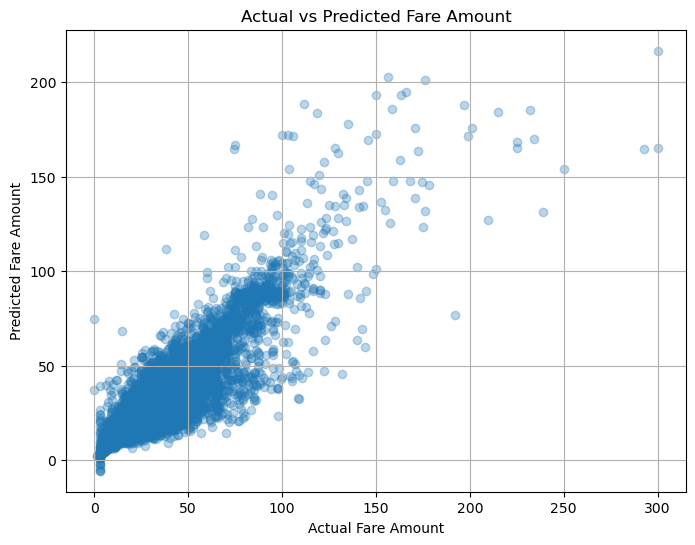

In [107]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, final_pred, alpha=0.3)

plt.xlabel("Actual Fare Amount")
plt.ylabel("Predicted Fare Amount")
plt.title("Actual vs Predicted Fare Amount")

plt.grid(True)
plt.show()

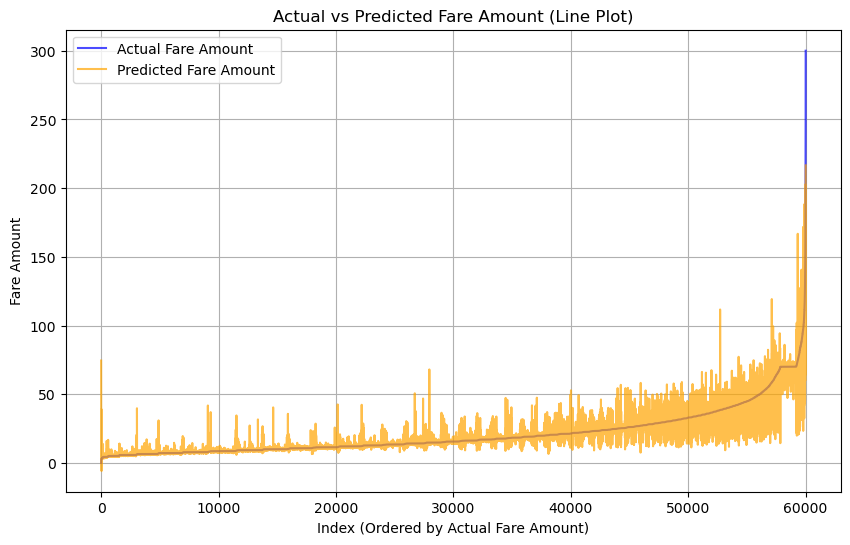

In [108]:
plt.figure(figsize=(10, 6))

# Sort actual and predicted values by actual fare amount for better visual comparison
sorted_indices = np.argsort(y_test)  # Sort indices based on actual fare values
sorted_actual = np.array(y_test)[sorted_indices]
sorted_predicted = np.array(final_pred)[sorted_indices]

# Plot the line for actual values
plt.plot(sorted_actual, label="Actual Fare Amount", color="blue", alpha=0.7)

# Plot the line for predicted values
plt.plot(sorted_predicted, label="Predicted Fare Amount", color="orange", alpha=0.7)

# Adding labels, title, and legend
plt.xlabel("Index (Ordered by Actual Fare Amount)")
plt.ylabel("Fare Amount")
plt.title("Actual vs Predicted Fare Amount (Line Plot)")
plt.legend()

# Show the plot
plt.grid(True)
plt.show()